In [6]:
from pathlib import Path

import pandas as pd

# Load the local data file from the workspace
file_path = Path('Data') / 'sales_cleaned.csv'

if file_path.exists():
    df_sales_cleaned = pd.read_csv(file_path, parse_dates=['Date'])
    df_sales_cleaned = df_sales_cleaned.sort_values('Date')
    print(f"Loaded '{file_path}' with shape {df_sales_cleaned.shape}")
    display(df_sales_cleaned.head())
else:
    print(f"Could not find data file at: {file_path.resolve()}")
    print("Please make sure the CSV exists inside the Data folder.")

Loaded 'Data\sales_cleaned.csv' with shape (3833, 3)


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [7]:
df_sales_cleaned = df_sales_cleaned.drop(columns=['COGS'])
df_sales_cleaned

,Date,Revenue
0,2012-07-04,5123547.94
1,2012-07-05,2751773.45
2,2012-07-06,3054029.42
3,2012-07-07,2667930.94
4,2012-07-08,2360851.90
...,...,...
3828,2022-12-27,2100553.66
3829,2022-12-28,3448729.20
3830,2022-12-29,3083944.33
3831,2022-12-30,2884668.76


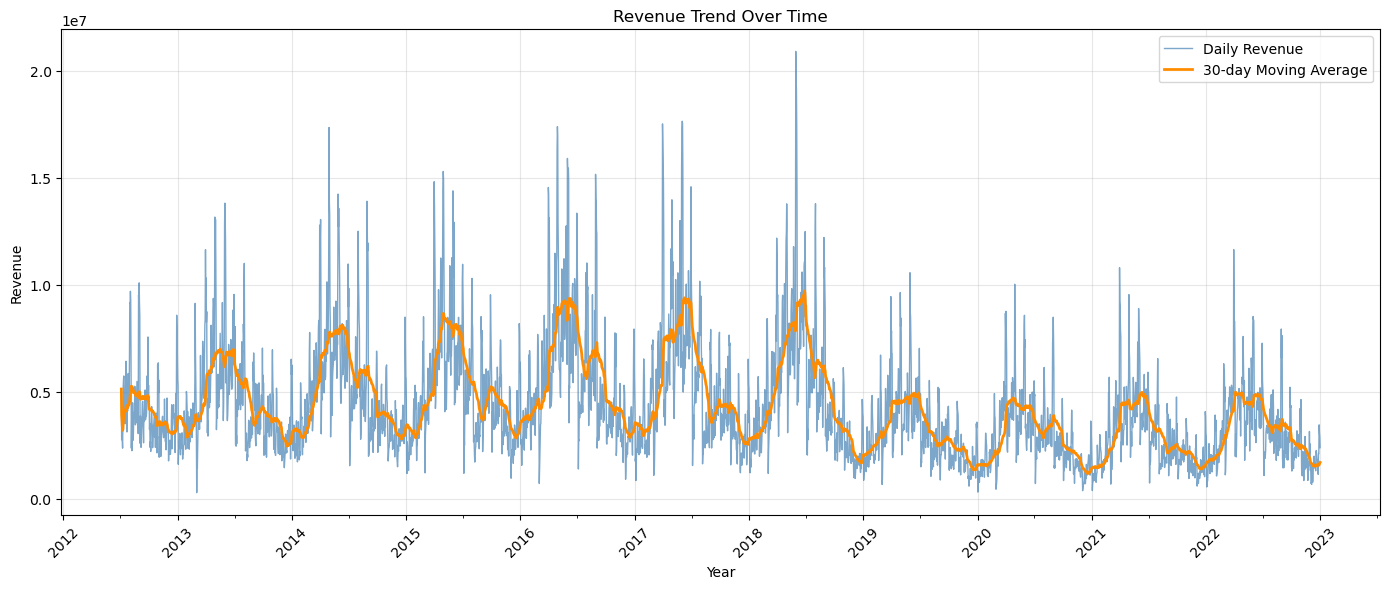

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Trend of Revenue over time
plot_df = df_sales_cleaned[['Date', 'Revenue']].copy().sort_values('Date')

plt.figure(figsize=(14, 6))
plt.plot(plot_df['Date'], plot_df['Revenue'], color='steelblue', linewidth=1, alpha=0.7, label='Daily Revenue')
plt.plot(plot_df['Date'], plot_df['Revenue'].rolling(window=30, min_periods=1).mean(), color='darkorange', linewidth=2, label='30-day Moving Average')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 7)))

plt.title('Revenue Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Missing days after reindexing: 0


C:\Users\lenovo\AppData\Local\Temp\ipykernel_21900\3175498317.py:45: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


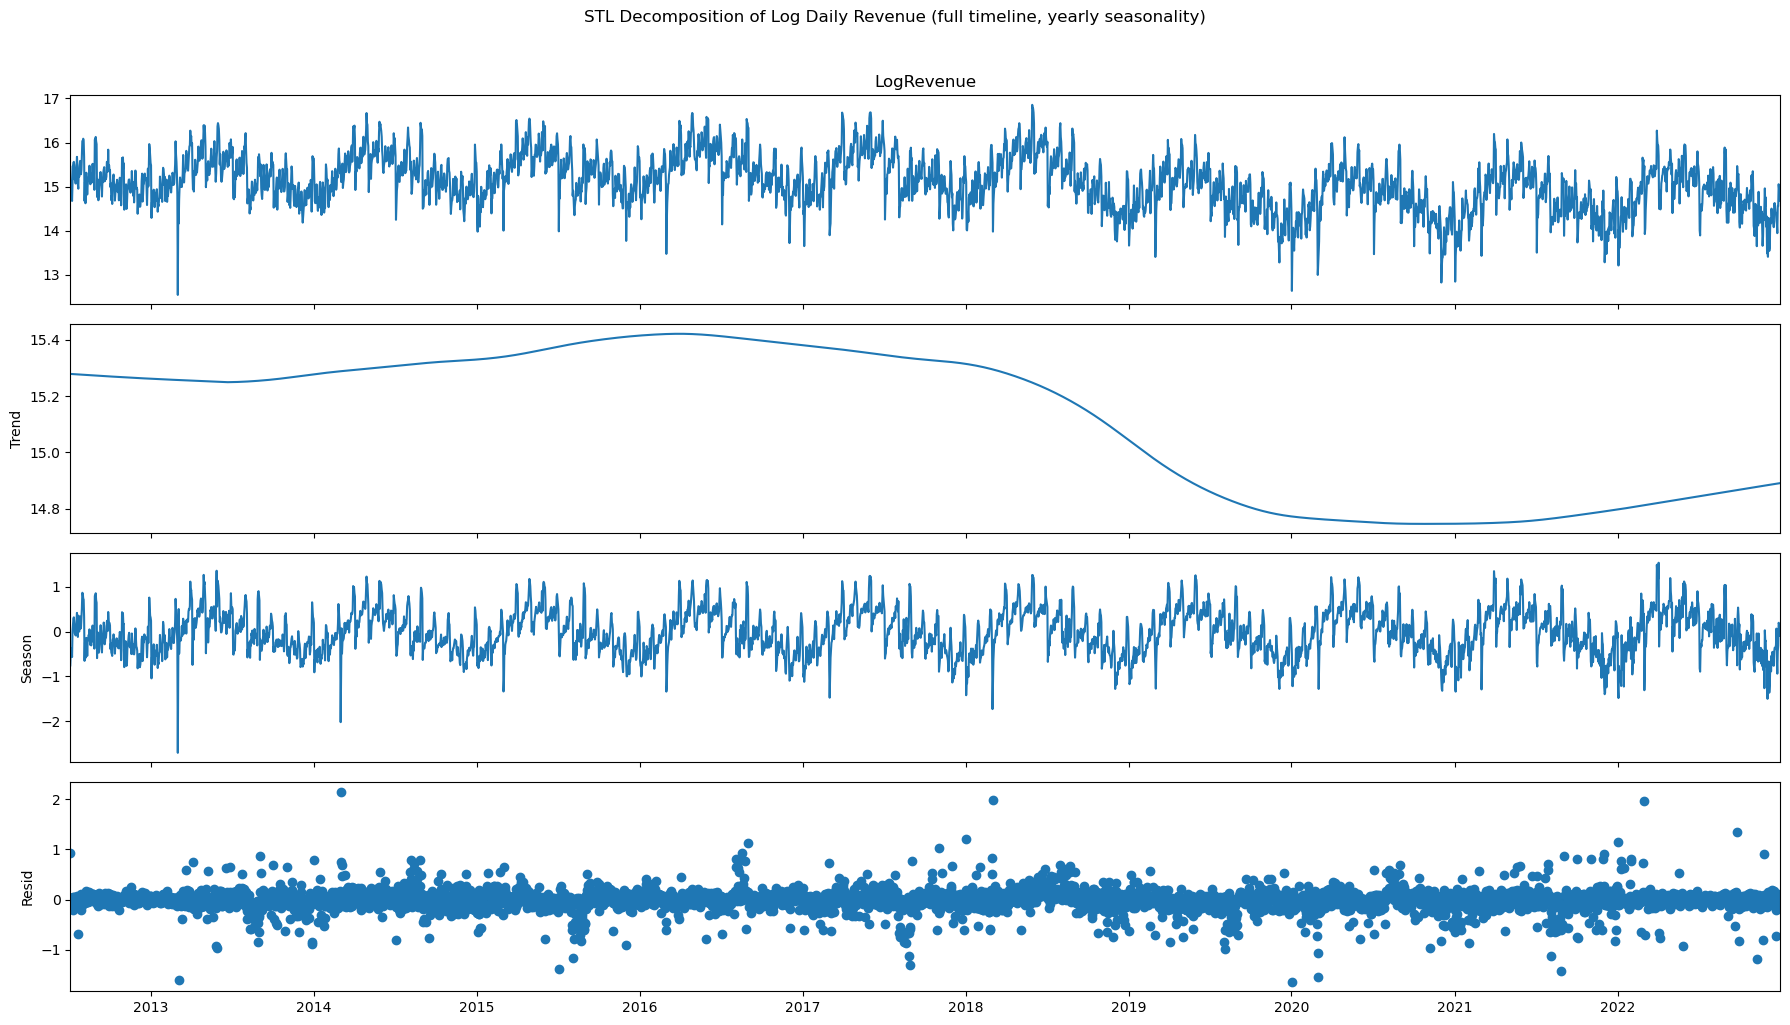

In [9]:
from statsmodels.tsa.seasonal import STL
import numpy as np
import matplotlib.pyplot as plt

# Chuan hoa chuoi doanh thu ve tan suat ngay de STL decomposition hoat dong on dinh
stl_df = (
    df_sales_cleaned[['Date', 'Revenue']]
    .drop_duplicates(subset='Date')
    .sort_values('Date')
    .set_index('Date')
    .asfreq('D')
)

missing_days = stl_df['Revenue'].isna().sum()
print(f'Missing days after reindexing: {missing_days}')

if missing_days > 0:
    stl_df['Revenue'] = stl_df['Revenue'].interpolate(method='time').ffill().bfill()

# Amplitude thay doi theo level => dung log transform de mo phong decomposition multiplicative
stl_df['LogRevenue'] = np.log(stl_df['Revenue'])

# Fit STL tren toan bo chuoi de bat seasonality nam
years = sorted(stl_df.index.year.unique())

def run_year_stl(segment, label):
    segment = segment.asfreq('D')
    if segment['LogRevenue'].isna().sum() > 0:
        segment['LogRevenue'] = segment['LogRevenue'].interpolate(method='time').ffill().bfill()

    period = 365
    if len(segment) <= period * 2:
        print(f'{label}: khong du du lieu de chay STL')
        return None

    result = STL(segment['LogRevenue'], period=period, robust=True).fit()
    return result

full_result = run_year_stl(stl_df[['LogRevenue']].copy(), 'Full series')

if full_result is not None:
    fig = full_result.plot()
    fig.set_size_inches(18, 10)
    fig.suptitle('STL Decomposition of Log Daily Revenue (full timeline, yearly seasonality)', y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
%pip install prophet --quiet

In [10]:
from statsmodels.tsa.stattools import adfuller

# Kiem tra tinh dung ADF tren log revenue va sai phan bac 1
adf_series = stl_df['LogRevenue'].dropna()
adf_diff_series = adf_series.diff().dropna()

def run_adf_test(series, label):
    result = adfuller(series, autolag='AIC')
    stat, p_value, used_lag, nobs, crit_values, icbest = result
    print(f'[{label}]')
    print(f'ADF Statistic: {stat:.6f}')
    print(f'p-value: {p_value:.6f}')
    print(f'Used Lag: {used_lag}')
    print(f'Observations: {nobs}')
    print('Critical Values:')
    for key, value in crit_values.items():
        print(f'  {key}: {value:.6f}')
    if p_value < 0.05:
        print('Conclusion: Reject H0 -> chuoi co tinh dung')
    else:
        print('Conclusion: Fail to reject H0 -> chuoi chua dung')
    print()

run_adf_test(adf_series, 'LogRevenue')
run_adf_test(adf_diff_series, 'LogRevenue first difference')

[LogRevenue]
ADF Statistic: -2.314354
p-value: 0.167380
Used Lag: 29
Observations: 3803
Critical Values:
  1%: -3.432071
  5%: -2.862300
  10%: -2.567175
Conclusion: Fail to reject H0 -> chuoi chua dung

[LogRevenue first difference]
ADF Statistic: -24.800849
p-value: 0.000000
Used Lag: 28
Observations: 3803
Critical Values:
  1%: -3.432071
  5%: -2.862300
  10%: -2.567175
Conclusion: Reject H0 -> chuoi co tinh dung



Note: you may need to restart the kernel to use updated packages.

==================== Fold 1 ====================
Train: up to 2019-12-31 | Test: 2020-01-01 to 2020-03-31


10:40:05 - cmdstanpy - INFO - Chain [1] start processing
10:40:05 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 1333226.64
MAE  (Revenue): 929583.26
MSE  (Revenue): 1777493271430.19
MAPE (Revenue): 41.99%
R^2 (Revenue): 0.2300
RMSE (Log): 0.5051
MAE  (Log): 0.4091


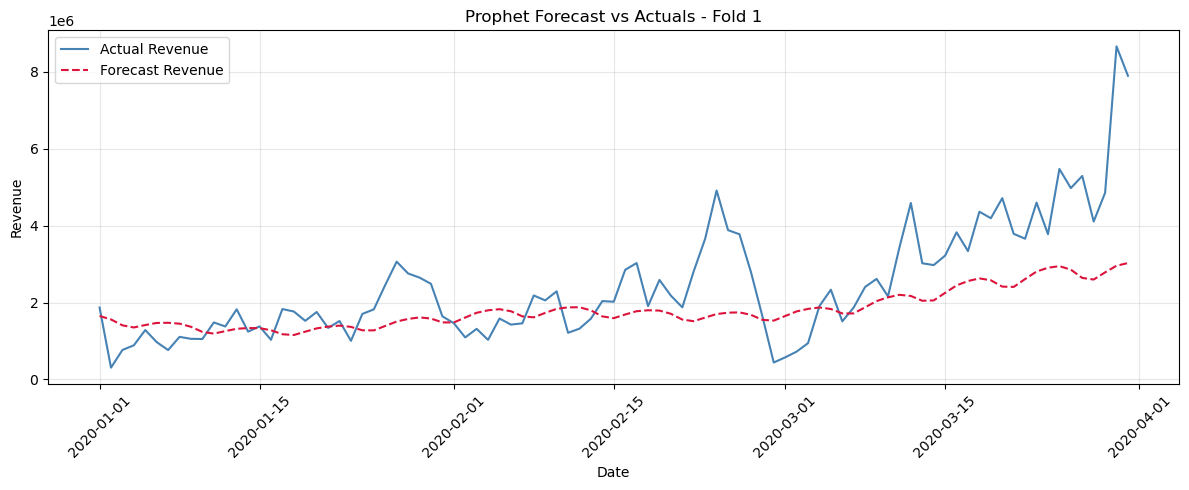


==================== Fold 2 ====================
Train: up to 2020-03-31 | Test: 2020-04-01 to 2020-06-30


10:40:07 - cmdstanpy - INFO - Chain [1] start processing
10:40:07 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 1924823.70
MAE  (Revenue): 1368328.88
MSE  (Revenue): 3704946262001.07
MAPE (Revenue): 28.85%
R^2 (Revenue): -0.4388
RMSE (Log): 0.4290
MAE  (Log): 0.3412


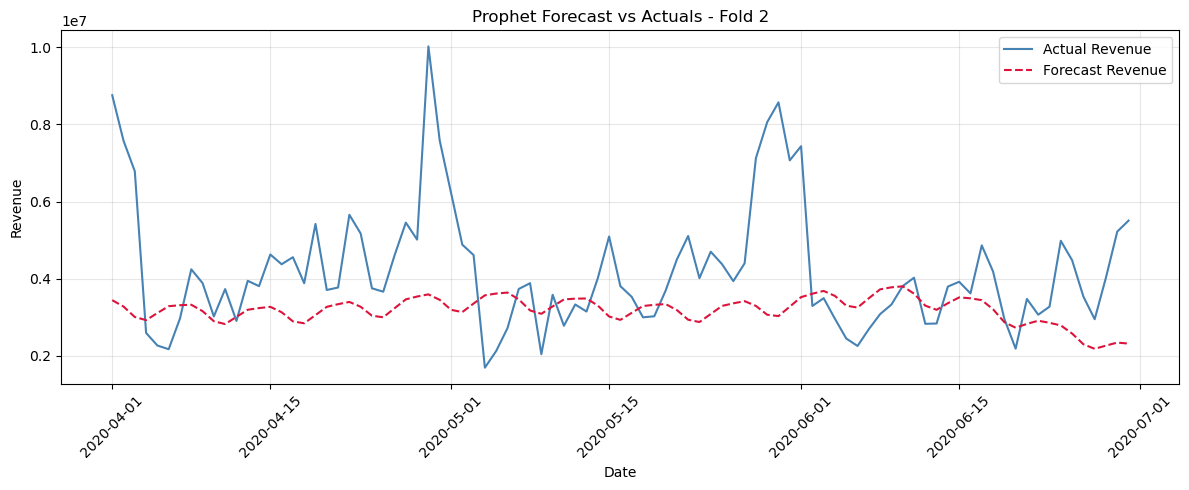


==================== Fold 3 ====================
Train: up to 2020-06-30 | Test: 2020-07-01 to 2020-09-30


10:40:09 - cmdstanpy - INFO - Chain [1] start processing
10:40:09 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 1727064.13
MAE  (Revenue): 1156475.88
MSE  (Revenue): 2982750523113.16
MAPE (Revenue): 32.02%
R^2 (Revenue): -0.5557
RMSE (Log): 0.5125
MAE  (Log): 0.3943


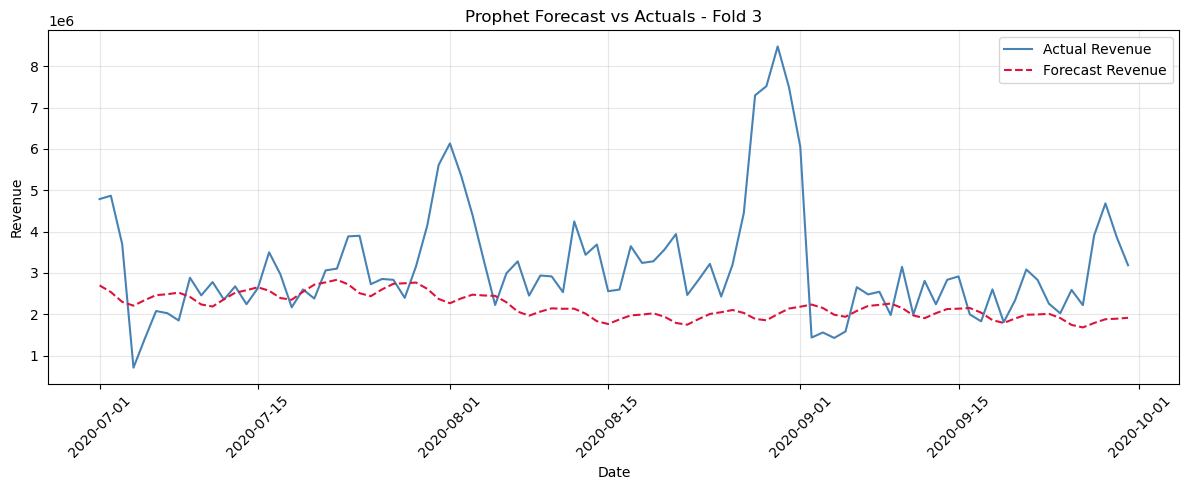


==================== Fold 4 ====================
Train: up to 2020-09-30 | Test: 2020-10-01 to 2020-12-31


10:40:11 - cmdstanpy - INFO - Chain [1] start processing
10:40:12 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 596251.60
MAE  (Revenue): 448771.22
MSE  (Revenue): 355515974807.55
MAPE (Revenue): 32.32%
R^2 (Revenue): 0.2768
RMSE (Log): 0.3668
MAE  (Log): 0.2776


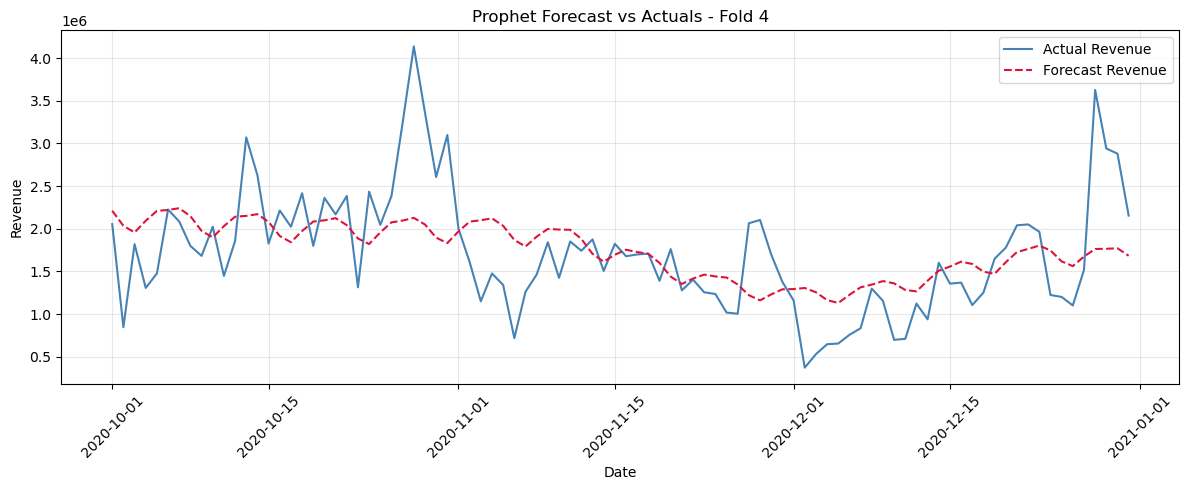


==================== Fold 5 ====================
Train: up to 2020-12-31 | Test: 2021-01-01 to 2021-03-31


10:40:14 - cmdstanpy - INFO - Chain [1] start processing
10:40:15 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 1316504.93
MAE  (Revenue): 805605.62
MSE  (Revenue): 1733185227291.51
MAPE (Revenue): 35.64%
R^2 (Revenue): 0.3583
RMSE (Log): 0.4372
MAE  (Log): 0.3396


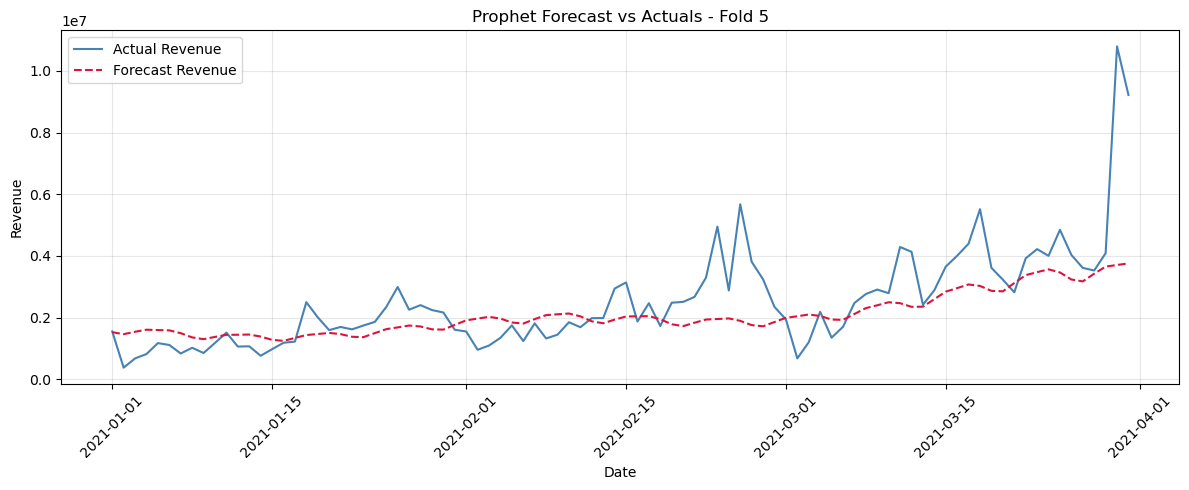


==================== Fold 6 ====================
Train: up to 2021-03-31 | Test: 2021-04-01 to 2021-06-30


10:40:16 - cmdstanpy - INFO - Chain [1] start processing
10:40:17 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 1723363.07
MAE  (Revenue): 1250898.22
MSE  (Revenue): 2969980258303.17
MAPE (Revenue): 26.81%
R^2 (Revenue): -0.1507
RMSE (Log): 0.3580
MAE  (Log): 0.2839


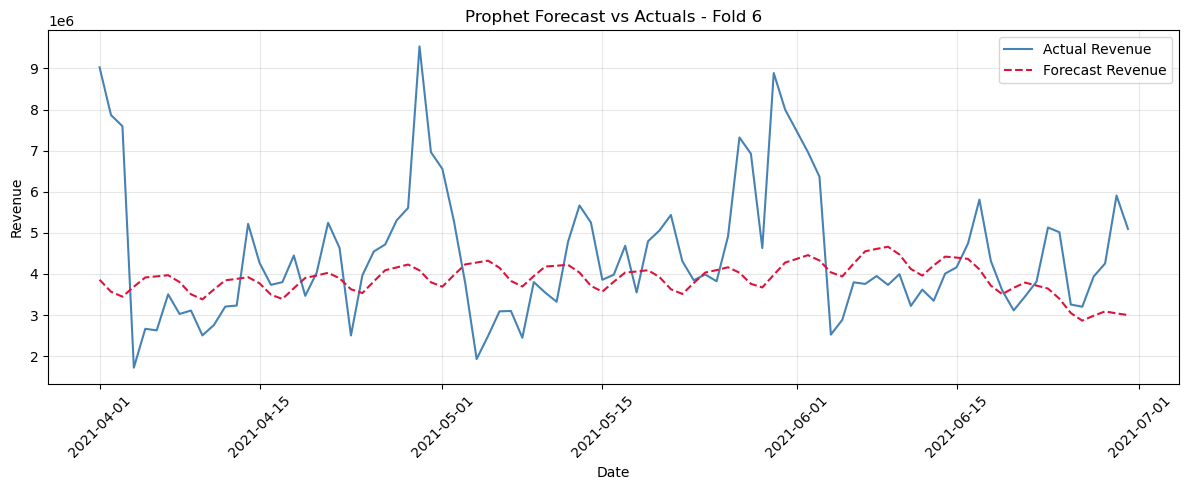


==================== Fold 7 ====================
Train: up to 2021-06-30 | Test: 2021-07-01 to 2021-09-30


10:40:19 - cmdstanpy - INFO - Chain [1] start processing
10:40:19 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 1001835.18
MAE  (Revenue): 766551.10
MSE  (Revenue): 1003673735672.62
MAPE (Revenue): 34.03%
R^2 (Revenue): 0.1589
RMSE (Log): 0.3786
MAE  (Log): 0.2961


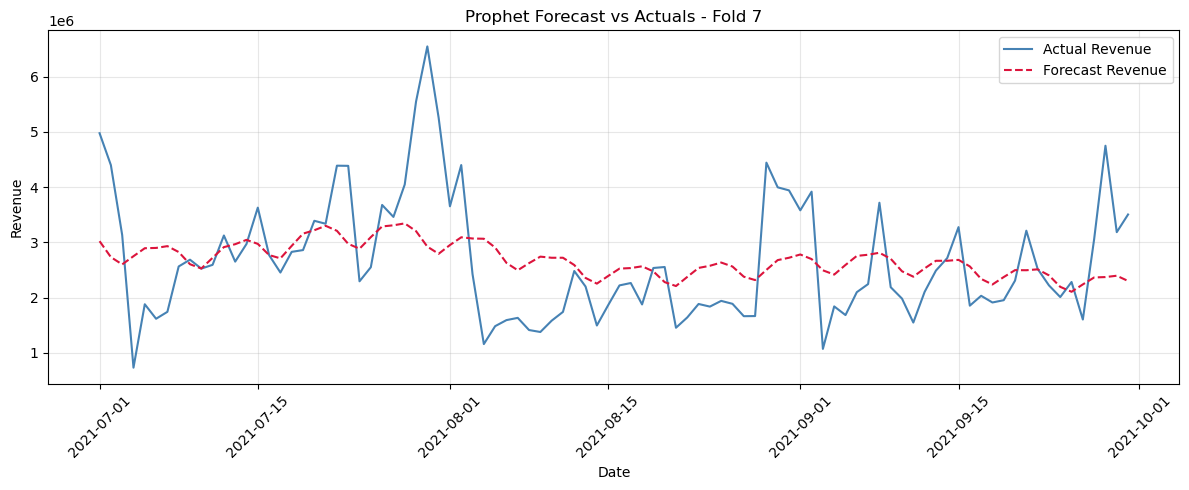


==================== Fold 8 ====================
Train: up to 2021-09-30 | Test: 2021-10-01 to 2021-12-31


10:40:21 - cmdstanpy - INFO - Chain [1] start processing
10:40:22 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 658983.27
MAE  (Revenue): 467886.24
MSE  (Revenue): 434258948497.62
MAPE (Revenue): 27.38%
R^2 (Revenue): 0.1243
RMSE (Log): 0.3424
MAE  (Log): 0.2612


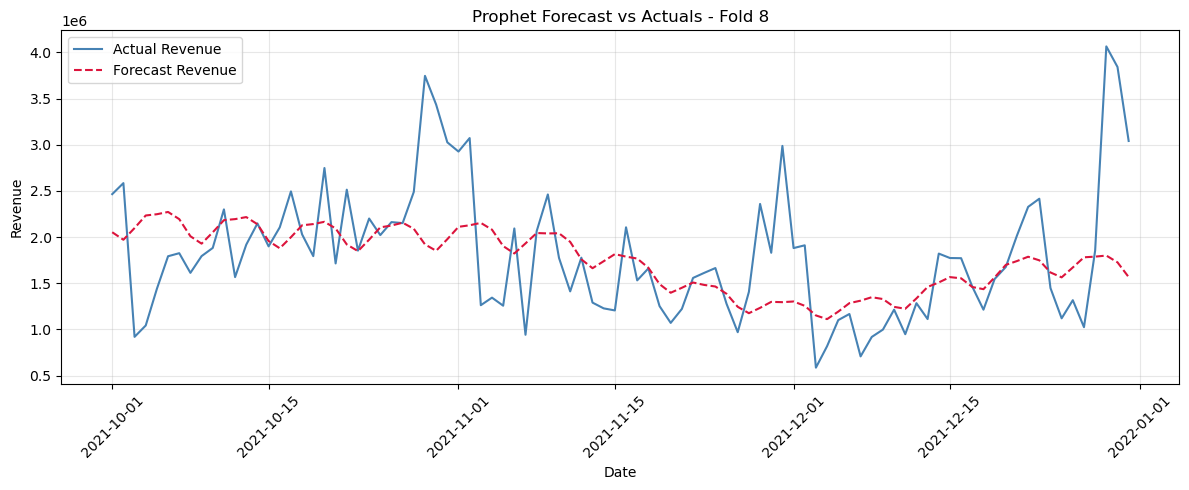


==================== Fold 9 ====================
Train: up to 2021-12-31 | Test: 2022-01-01 to 2022-03-31


10:40:24 - cmdstanpy - INFO - Chain [1] start processing
10:40:24 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 1599531.97
MAE  (Revenue): 1097359.08
MSE  (Revenue): 2558502536641.33
MAPE (Revenue): 34.46%
R^2 (Revenue): 0.1841
RMSE (Log): 0.4675
MAE  (Log): 0.3874


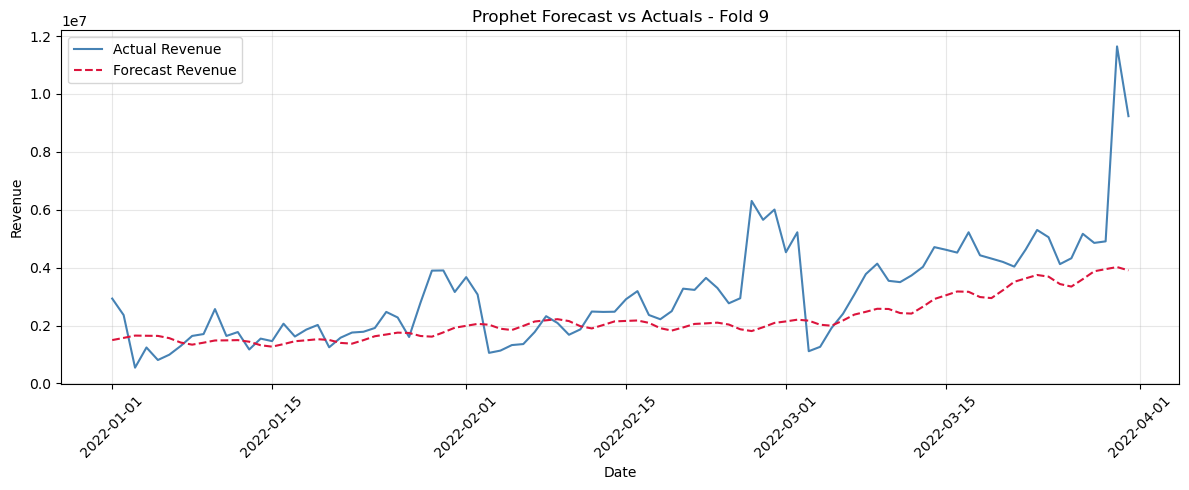


==================== Fold 10 ====================
Train: up to 2022-03-31 | Test: 2022-04-01 to 2022-06-30


10:40:26 - cmdstanpy - INFO - Chain [1] start processing
10:40:27 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 1619051.25
MAE  (Revenue): 1219907.46
MSE  (Revenue): 2621326943513.21
MAPE (Revenue): 28.79%
R^2 (Revenue): -0.1004
RMSE (Log): 0.3541
MAE  (Log): 0.2745


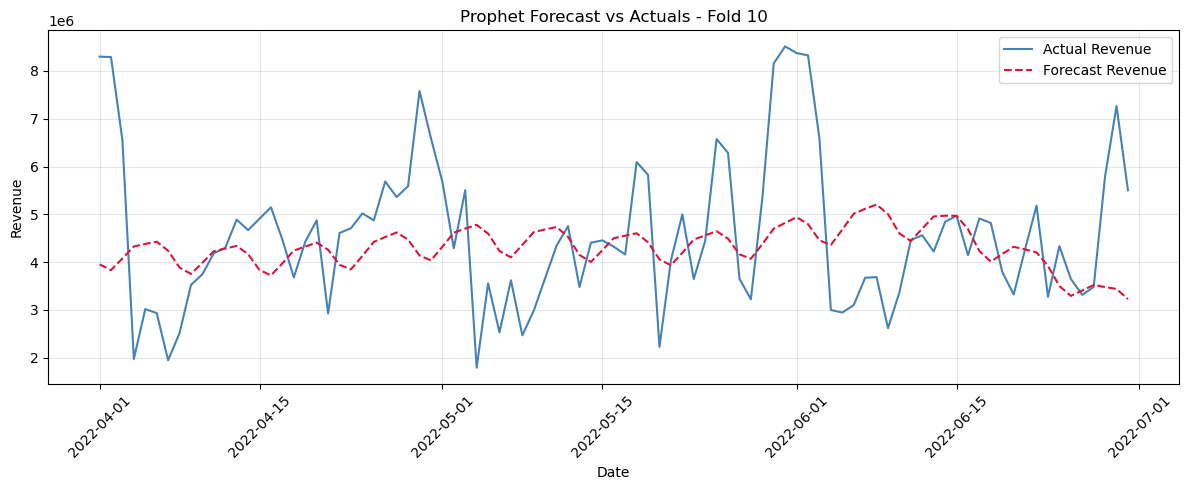


==================== Fold 11 ====================
Train: up to 2022-06-30 | Test: 2022-07-01 to 2022-09-30


10:40:28 - cmdstanpy - INFO - Chain [1] start processing
10:40:29 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 1354445.06
MAE  (Revenue): 915880.79
MSE  (Revenue): 1834521428224.33
MAPE (Revenue): 28.62%
R^2 (Revenue): -0.0764
RMSE (Log): 0.3833
MAE  (Log): 0.2890


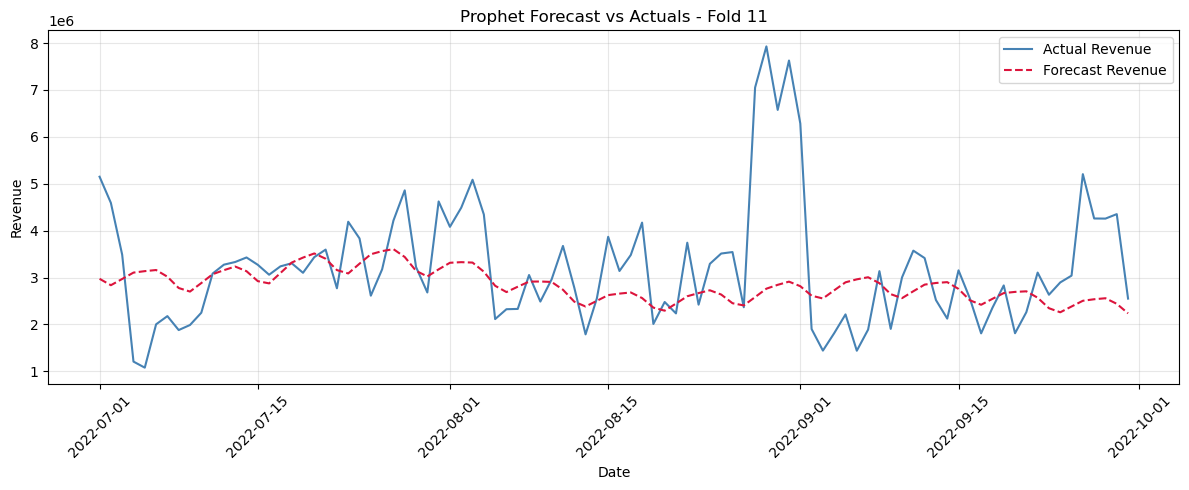


==================== Fold 12 ====================
Train: up to 2022-09-30 | Test: 2022-10-01 to 2022-12-31


10:40:31 - cmdstanpy - INFO - Chain [1] start processing
10:40:31 - cmdstanpy - INFO - Chain [1] done processing


RMSE (Revenue): 685546.27
MAE  (Revenue): 520031.39
MSE  (Revenue): 469973688159.58
MAPE (Revenue): 31.32%
R^2 (Revenue): 0.1520
RMSE (Log): 0.3562
MAE  (Log): 0.2749


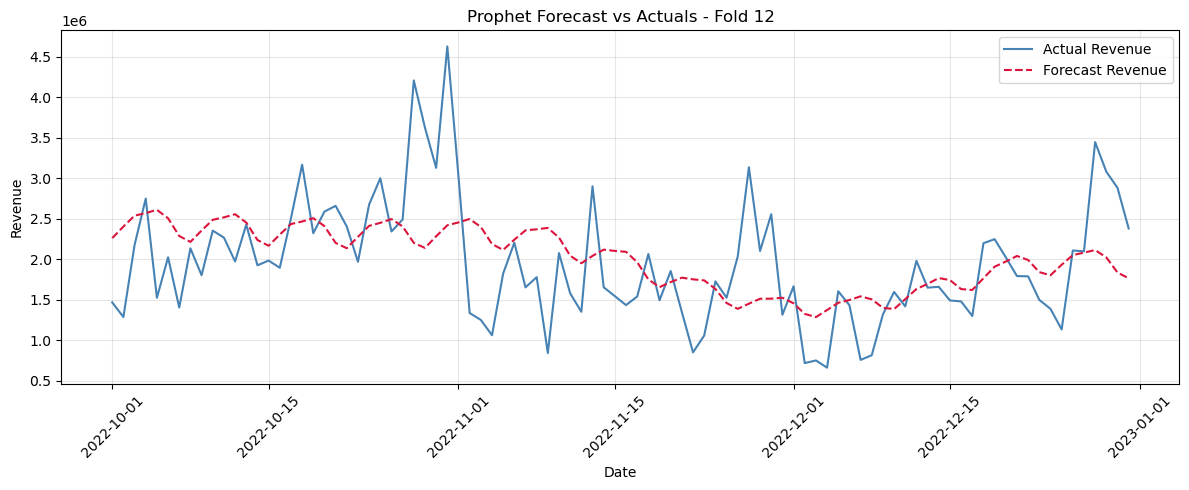


==================== FOLD RESULTS ====================


,fold,train_end,test_start,test_end,RMSE_Revenue,MAE_Revenue,MSE_Revenue,MAPE_Revenue,R2_Revenue,RMSE_Log,MAE_Log
0,1,2019-12-31,2020-01-01,2020-03-31,1.333227e+06,9.295833e+05,1.777493e+12,41.993118,0.229962,0.505072,0.409059
1,2,2020-03-31,2020-04-01,2020-06-30,1.924824e+06,1.368329e+06,3.704946e+12,28.851771,-0.438834,0.429030,0.341244
2,3,2020-06-30,2020-07-01,2020-09-30,1.727064e+06,1.156476e+06,2.982751e+12,32.019702,-0.555737,0.512489,0.394250
3,4,2020-09-30,2020-10-01,2020-12-31,5.962516e+05,4.487712e+05,3.555160e+11,32.324759,0.276802,0.366787,0.277569
4,5,2020-12-31,2021-01-01,2021-03-31,1.316505e+06,8.056056e+05,1.733185e+12,35.637583,0.358300,0.437180,0.339634
5,6,2021-03-31,2021-04-01,2021-06-30,1.723363e+06,1.250898e+06,2.969980e+12,26.809213,-0.150679,0.358028,0.283909
6,7,2021-06-30,2021-07-01,2021-09-30,1.001835e+06,7.665511e+05,1.003674e+12,34.025439,0.158936,0.378622,0.296074
7,8,2021-09-30,2021-10-01,2021-12-31,6.589833e+05,4.678862e+05,4.342589e+11,27.375282,0.124340,0.342449,0.261244
8,9,2021-12-31,2022-01-01,2022-03-31,1.599532e+06,1.097359e+06,2.558503e+12,34.456154,0.184147,0.467546,0.387356
9,10,2022-03-31,2022-04-01,2022-06-30,1.619051e+06,1.219907e+06,2.621327e+12,28.790564,-0.100380,0.354052,0.274479



==================== AVERAGE OF 5 FOLDS ====================


,Average_5_Folds
RMSE_Revenue,1.295052e+06
MAE_Revenue,9.122733e+05
MSE_Revenue,1.870511e+12
MAPE_Revenue,3.185266e+01
R2_Revenue,1.353799e-02
RMSE_Log,4.075602e-01
MAE_Log,3.190574e-01



==================== OVERALL POOLED RESULT ====================
Overall RMSE: 1366099.84
Overall MAE : 911108.61


In [27]:
%pip install prophet --quiet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from importlib import import_module
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Prophet = import_module('prophet').Prophet

# =========================
# 5-FOLD EXPANDING WINDOW CONFIG
# =========================
splits_config = [
    # === GIAI ĐOẠN SUY GIẢM (2020) ===
    {'fold': 1, 'train_end': '2019-12-31', 'test_start': '2020-01-01', 'test_end': '2020-03-31'},
    {'fold': 2, 'train_end': '2020-03-31', 'test_start': '2020-04-01', 'test_end': '2020-06-30'},
    {'fold': 3, 'train_end': '2020-06-30', 'test_start': '2020-07-01', 'test_end': '2020-09-30'},
    {'fold': 4, 'train_end': '2020-09-30', 'test_start': '2020-10-01', 'test_end': '2020-12-31'},
    
    # === GIAI ĐOẠN HỒI PHỤC (2021) ===
    {'fold': 5, 'train_end': '2020-12-31', 'test_start': '2021-01-01', 'test_end': '2021-03-31'},
    {'fold': 6, 'train_end': '2021-03-31', 'test_start': '2021-04-01', 'test_end': '2021-06-30'},
    {'fold': 7, 'train_end': '2021-06-30', 'test_start': '2021-07-01', 'test_end': '2021-09-30'},
    {'fold': 8, 'train_end': '2021-09-30', 'test_start': '2021-10-01', 'test_end': '2021-12-31'},
    
    # === GIAI ĐOẠN ỔN ĐỊNH (2022) ===
    {'fold': 9,  'train_end': '2021-12-31', 'test_start': '2022-01-01', 'test_end': '2022-03-31'},
    {'fold': 10, 'train_end': '2022-03-31', 'test_start': '2022-04-01', 'test_end': '2022-06-30'},
    {'fold': 11, 'train_end': '2022-06-30', 'test_start': '2022-07-01', 'test_end': '2022-09-30'},
    {'fold': 12, 'train_end': '2022-09-30', 'test_start': '2022-10-01', 'test_end': '2022-12-31'},
]

fold_rows = []
all_test_preds = []
all_test_actuals = []

# =========================
# MODEL LOOP
# =========================
for split in splits_config:
    fold = split['fold']
    print(f"\n==================== Fold {fold} ====================")
    print(f"Train: up to {split['train_end']} | Test: {split['test_start']} to {split['test_end']}")

    train = stl_df.loc[:split['train_end'], ['LogRevenue']].reset_index()
    test = stl_df.loc[split['test_start']:split['test_end'], ['LogRevenue']].reset_index()

    train = train.rename(columns={'Date': 'ds', 'LogRevenue': 'y'})
    test = test.rename(columns={'Date': 'ds', 'LogRevenue': 'y'})

    model = Prophet(yearly_seasonality='auto', daily_seasonality=False)
    model.fit(train)

    future = test[['ds']].copy()
    forecast = model.predict(future)[['ds', 'yhat']]

    y_true_log = test['y'].to_numpy()
    y_pred_log = forecast['yhat'].to_numpy()
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)

    rmse_revenue = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_revenue = mean_absolute_error(y_true, y_pred)
    mse_revenue = mean_squared_error(y_true, y_pred)
    mape_revenue = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2_revenue = r2_score(y_true, y_pred)

    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)

    fold_rows.append({
        'fold': fold,
        'train_end': split['train_end'],
        'test_start': split['test_start'],
        'test_end': split['test_end'],
        'RMSE_Revenue': rmse_revenue,
        'MAE_Revenue': mae_revenue,
        'MSE_Revenue': mse_revenue,
        'MAPE_Revenue': mape_revenue,
        'R2_Revenue': r2_revenue,
        'RMSE_Log': rmse_log,
        'MAE_Log': mae_log,
    })

    all_test_preds.extend(y_pred)
    all_test_actuals.extend(y_true)

    print(f"RMSE (Revenue): {rmse_revenue:.2f}")
    print(f"MAE  (Revenue): {mae_revenue:.2f}")
    print(f"MSE  (Revenue): {mse_revenue:.2f}")
    print(f"MAPE (Revenue): {mape_revenue:.2f}%")
    print(f"R^2 (Revenue): {r2_revenue:.4f}")
    print(f"RMSE (Log): {rmse_log:.4f}")
    print(f"MAE  (Log): {mae_log:.4f}")

    plt.figure(figsize=(12, 5))
    plt.plot(test['ds'], y_true, label='Actual Revenue', color='steelblue')
    plt.plot(forecast['ds'], y_pred, label='Forecast Revenue', linestyle='--', color='crimson')
    plt.title(f'Prophet Forecast vs Actuals - Fold {fold}')
    plt.xlabel('Date')
    plt.ylabel('Revenue')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =========================
# SUMMARY TABLE + AVERAGE OF 5 FOLDS
# =========================
fold_results = pd.DataFrame(fold_rows)
print('\n==================== FOLD RESULTS ====================')
display(fold_results)

avg_results = fold_results[[
    'RMSE_Revenue', 'MAE_Revenue', 'MSE_Revenue', 'MAPE_Revenue', 'R2_Revenue', 'RMSE_Log', 'MAE_Log'
]].mean().to_frame(name='Average_5_Folds')

print('\n==================== AVERAGE OF 5 FOLDS ====================')
display(avg_results)

overall_rmse = np.sqrt(mean_squared_error(all_test_actuals, all_test_preds))
overall_mae = mean_absolute_error(all_test_actuals, all_test_preds)
print('\n==================== OVERALL POOLED RESULT ====================')
print(f'Overall RMSE: {overall_rmse:.2f}')
print(f'Overall MAE : {overall_mae:.2f}')

WHITE NOISE TEST ON RESIDUALS (Slide 82-86)

[1] SUMMARY STATISTICS
Mean: 425327.157882
Std Dev: 1298200.899087
Variance: 1685325574389.191406
Min: -2987424.929193
Max: 7622243.795779
Skewness: 1.614307
Kurtosis: 4.306100

[2] LINE PLOT - Visual inspection for trends/patterns

[3] HISTOGRAM - Check for normality (Slide 85)

[4] AUTOCORRELATION PLOT (ACF)

[5] PARTIAL AUTOCORRELATION PLOT (PACF)


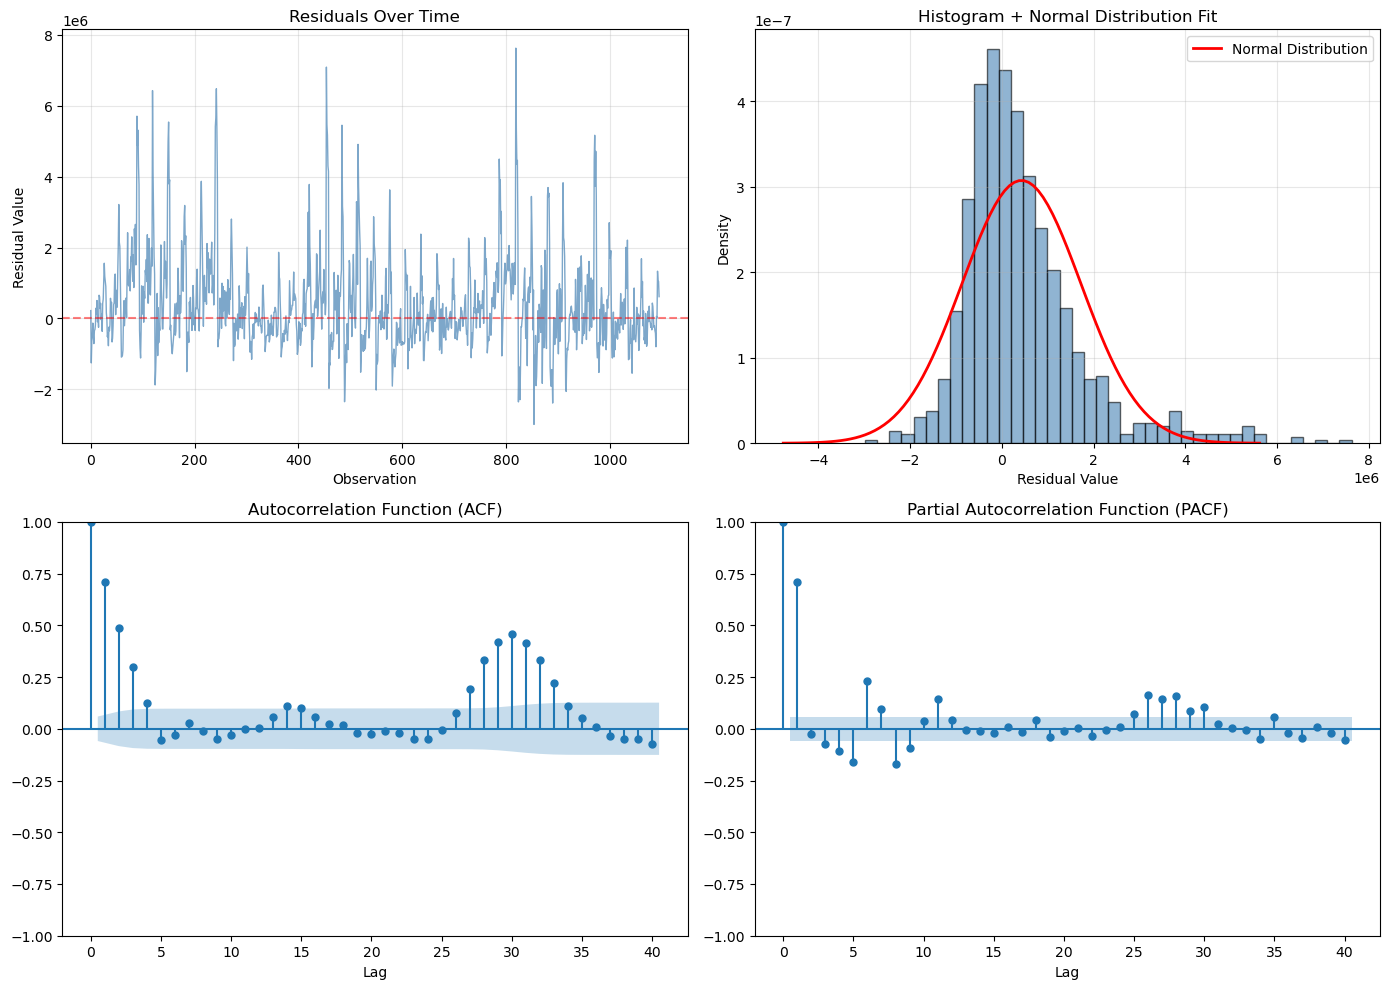


STATISTICAL TESTS FOR WHITE NOISE

[6] LJUNG-BOX TEST (Correlogram-based)
H0: No autocorrelation (i.e., White Noise)
H1: Autocorrelation exists (i.e., NOT White Noise)
       lb_stat      lb_pvalue
1   551.196428  6.913832e-122
2   813.074273  2.774373e-177
3   911.458720  2.894263e-197
4   928.713226  1.000625e-199
5   931.860692  3.382708e-199
6   932.868218  2.942071e-198
7   933.681453  2.554590e-197
8   933.779268  2.915368e-196
9   936.308093  9.273623e-196
10  937.305368  5.937906e-195

Conclusion (α=0.05): ✗ NOT WHITE NOISE

[7] JARQUE-BERA TEST (Normality)
H0: Data is normally distributed
JB Statistic: 1322.800794
p-value: 0.000000
✗ Residuals are NOT normally distributed

[8] AUGMENTED DICKEY-FULLER TEST
H0: Unit root exists (non-stationary)
ADF Statistic: -8.272576
p-value: 0.000000
✓ Residuals are stationary

FINAL ASSESSMENT (Slide 82-86 Criteria)
✓ Mean close to 0: False
✓ Constant variance: Visual inspection needed
✓ No autocorrelation: False
✓ Normally distributed: Fal

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

# =========================
# EXTRACT RESIDUALS FROM PROPHET FORECAST
# =========================
residuals = np.array(all_test_actuals) - np.array(all_test_preds)

print("="*70)
print("WHITE NOISE TEST ON RESIDUALS (Slide 82-86)")
print("="*70)

# ===== 1. SUMMARY STATISTICS =====
print("\n[1] SUMMARY STATISTICS")
print(f"Mean: {np.mean(residuals):.6f}")
print(f"Std Dev: {np.std(residuals):.6f}")
print(f"Variance: {np.var(residuals):.6f}")
print(f"Min: {np.min(residuals):.6f}")
print(f"Max: {np.max(residuals):.6f}")
print(f"Skewness: {stats.skew(residuals):.6f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.6f}")

# ===== 2. LINE PLOT =====
print("\n[2] LINE PLOT - Visual inspection for trends/patterns")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Line plot
axes[0, 0].plot(residuals, linewidth=1, alpha=0.7, color='steelblue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_xlabel('Observation')
axes[0, 0].set_ylabel('Residual Value')
axes[0, 0].grid(True, alpha=0.3)

# ===== 3. HISTOGRAM + NORMAL DISTRIBUTION FIT =====
print("\n[3] HISTOGRAM - Check for normality (Slide 85)")
mu, sigma = np.mean(residuals), np.std(residuals)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)

axes[0, 1].hist(residuals, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='black')
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
axes[0, 1].set_title('Histogram + Normal Distribution Fit')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ===== 4. ACF PLOT =====
print("\n[4] AUTOCORRELATION PLOT (ACF)")
plot_acf(residuals, lags=40, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Function (ACF)')
axes[1, 0].set_xlabel('Lag')

# ===== 5. PACF PLOT =====
print("\n[5] PARTIAL AUTOCORRELATION PLOT (PACF)")
plot_pacf(residuals, lags=40, ax=axes[1, 1])
axes[1, 1].set_title('Partial Autocorrelation Function (PACF)')
axes[1, 1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

# ===== 6. STATISTICAL TESTS =====
print("\n" + "="*70)
print("STATISTICAL TESTS FOR WHITE NOISE")
print("="*70)

# Ljung-Box Test (Slide 86 - Correlogram test)
print("\n[6] LJUNG-BOX TEST (Correlogram-based)")
print("H0: No autocorrelation (i.e., White Noise)")
print("H1: Autocorrelation exists (i.e., NOT White Noise)")
lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)
print(lb_test)

# Interpretation
alpha = 0.05
all_white = (lb_test['lb_pvalue'] > alpha).all()
print(f"\nConclusion (α={alpha}): {'✓ WHITE NOISE' if all_white else '✗ NOT WHITE NOISE'}")

# Jarque-Bera Test (Normality test)
print("\n[7] JARQUE-BERA TEST (Normality)")
print("H0: Data is normally distributed")
jb_stat, jb_pval, jb_skew, jb_kurt = jarque_bera(residuals)
print(f"JB Statistic: {jb_stat:.6f}")
print(f"p-value: {jb_pval:.6f}")
if jb_pval > 0.05:
    print("✓ Residuals are normally distributed")
else:
    print("✗ Residuals are NOT normally distributed")

# ADF Test on Residuals
print("\n[8] AUGMENTED DICKEY-FULLER TEST")
print("H0: Unit root exists (non-stationary)")
adf_result = adfuller(residuals, autolag='AIC')
print(f"ADF Statistic: {adf_result[0]:.6f}")
print(f"p-value: {adf_result[1]:.6f}")
if adf_result[1] < 0.05:
    print("✓ Residuals are stationary")
else:
    print("✗ Residuals are NOT stationary")

# ===== SUMMARY CONCLUSION =====
print("\n" + "="*70)
print("FINAL ASSESSMENT (Slide 82-86 Criteria)")
print("="*70)
print(f"✓ Mean close to 0: {abs(np.mean(residuals)) < 0.1}")
print(f"✓ Constant variance: Visual inspection needed")
print(f"✓ No autocorrelation: {all_white}")
print(f"✓ Normally distributed: {jb_pval > 0.05}")
print(f"✓ Stationary: {adf_result[1] < 0.05}")

white_noise_criteria_met = (
    abs(np.mean(residuals)) < 0.1 and 
    all_white and 
    jb_pval > 0.05 and 
    adf_result[1] < 0.05
)
print("\n" + "="*70)
if white_noise_criteria_met:
    print("✓✓✓ RESIDUALS ARE WHITE NOISE ✓✓✓")
else:
    print("✗✗✗ RESIDUALS ARE NOT PURE WHITE NOISE ✗✗✗")
    if not all_white:
        print("  → Issue: Still contains autocorrelation")
    if jb_pval < 0.05:
        print("  → Issue: Not normally distributed")
    if adf_result[1] >= 0.05:
        print("  → Issue: May contain unit root")
print()